# 02 — PCA vs ICA Component Comparison and Interpretation

This notebook is the **future-direction analysis notebook**.

It is designed to help you answer:

- what are the top components from PCA and ICA?
- how are they similar and different?
- are they spatially matched?
- do matched components behave similarly across subjects?
- does PCA capture broader variance-driven structure while ICA captures more separated source-like structure?

This notebook assumes you already have:

- PCA component image: `group_pca_K20_components.nii.gz`
- ICA component image: `group_ica_K20_components.nii.gz`
- PCA static features CSV
- ICA static features CSV
- labels CSV
- optionally per-subject time course files if you want extra score-based comparisons later


In [1]:

from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nibabel as nib
from scipy.optimize import linear_sum_assignment
from scipy.stats import zscore, pearsonr

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score


In [2]:

# -----------------------------
# Edit these paths
# -----------------------------
ROOT_PCA = Path("/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewPCA2")
ROOT_ICA = Path("/Users/onilarasanjala/Desktop/TSeme/CogNeuSci/CodeData/NewICA")
OUTDIR = Path("./results_pca_ica_comparison")
OUTDIR.mkdir(parents=True, exist_ok=True)

K = 20
RANDOM_STATE = 42
THRESHOLD_Z = 2.0  # threshold for Dice overlap on z-scored maps


In [3]:

@dataclass
class MethodConfig:
    name: str
    prefix: str
    components_img: Path
    static_features_csv: Path
    labels_csv: Path

pca_cfg = MethodConfig(
    name="PCA",
    prefix="PC",
    components_img=ROOT_PCA / f"group_pca_K{K}_components.nii.gz",
    static_features_csv=ROOT_PCA / f"features_static_nonZ_K{K}.csv",
    labels_csv=ROOT_PCA / "proficiency_labels.csv",
)

ica_cfg = MethodConfig(
    name="ICA",
    prefix="IC",
    components_img=ROOT_ICA / f"group_ica_K{K}_components.nii.gz",
    static_features_csv=ROOT_ICA / f"features_static_nonZ_K{K}.csv",
    labels_csv=ROOT_ICA / "proficiency_labels.csv",
)


## 1) Utility functions


In [4]:

def fixed_pipeline(C: float = 1.0, penalty: str = "l2") -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",
            C=C,
            penalty=penalty,
            max_iter=5000,
            random_state=RANDOM_STATE,
        ))
    ])

def infer_subject_column(df: pd.DataFrame) -> str:
    for c in ["subject", "sub", "participant_id", "participant", "Subject"]:
        if c in df.columns:
            return c
    raise ValueError("Could not find subject column.")

def infer_label_column(df: pd.DataFrame) -> str:
    for c in ["y", "label", "proficiency", "group", "advanced", "class", "target"]:
        if c in df.columns:
            return c
    raise ValueError("Could not infer label column.")

def normalize_subject_ids(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    return s.str.replace(r"^(?!sub-)(\d+$)", lambda m: f"sub-{int(m.group(1)):02d}", regex=True)

def load_labels(labels_csv: Path) -> pd.DataFrame:
    ydf = pd.read_csv(labels_csv)
    sub_col = infer_subject_column(ydf)
    lab_col = infer_label_column(ydf)
    out = ydf[[sub_col, lab_col]].copy()
    out.columns = ["subject", "label_raw"]
    out["subject"] = normalize_subject_ids(out["subject"])

    if pd.api.types.is_numeric_dtype(out["label_raw"]):
        out["y"] = out["label_raw"].astype(int)
    else:
        s = out["label_raw"].astype(str).str.lower().str.strip()
        mapping = {"advanced": 1, "adv": 1, "1": 1, "intermediate": 0, "int": 0, "0": 0}
        out["y"] = s.map(mapping)
        if out["y"].isna().any():
            raise ValueError("Unmapped labels found.")
        out["y"] = out["y"].astype(int)
    return out[["subject", "y"]].drop_duplicates()

def load_static_features(csv_path: Path, labels_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    sub_col = infer_subject_column(df)
    df = df.rename(columns={sub_col: "subject"})
    df["subject"] = normalize_subject_ids(df["subject"])

    labels = load_labels(labels_csv)
    out = df.merge(labels, on="subject", how="inner")
    if out.empty:
        raise ValueError(f"No overlap between {csv_path.name} and labels.")
    return out

def feature_columns(df: pd.DataFrame) -> List[str]:
    excluded = {"subject", "y", "label", "label_raw", "group", "class", "target"}
    return [c for c in df.columns if c not in excluded and pd.api.types.is_numeric_dtype(df[c])]

def component_id_from_feature(col: str, prefix: str) -> Optional[str]:
    m = re.search(rf"({prefix}\d+)", col)
    return m.group(1) if m else None

def component_group_importance_from_coef(coef: np.ndarray, columns: List[str], prefix: str) -> pd.DataFrame:
    rows = []
    for w, c in zip(coef, columns):
        cid = component_id_from_feature(c, prefix)
        if cid is None:
            continue
        rows.append((cid, c, float(w), abs(float(w))))
    df = pd.DataFrame(rows, columns=["component", "feature", "coef", "abs_coef"])
    if df.empty:
        return df
    grp = df.groupby("component", as_index=False)["abs_coef"].sum().rename(columns={"abs_coef": "importance"})
    grp["component_num"] = grp["component"].str.extract(r"(\d+)").astype(int)
    grp = grp.sort_values(["importance", "component_num"], ascending=[False, True]).reset_index(drop=True)
    return grp

def fit_full_model_importance(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    cols = feature_columns(df)
    X = df[cols].to_numpy(dtype=float)
    y = df["y"].to_numpy(dtype=int)
    model = fixed_pipeline(C=1.0, penalty="l2").fit(X, y)
    coef = model.named_steps["clf"].coef_.ravel()
    return component_group_importance_from_coef(coef, cols, prefix)

def loocv_auc_for_feature_matrix(X: np.ndarray, y: np.ndarray) -> float:
    loo = LeaveOneOut()
    scores = np.zeros(len(y), dtype=float)
    for tr, te in loo.split(X, y):
        clf = fixed_pipeline(C=1.0, penalty="l2")
        clf.fit(X[tr], y[tr])
        scores[te[0]] = clf.predict_proba(X[te])[0, 1]
    return roc_auc_score(y, scores)

def component_specific_feature_cols(df: pd.DataFrame, component_id: str) -> List[str]:
    pattern = re.compile(rf"\b{re.escape(component_id)}\b|{re.escape(component_id)}")
    cols = [c for c in feature_columns(df) if pattern.search(c)]
    return cols

def single_component_auc_table(df: pd.DataFrame, prefix: str, max_components: int = 999) -> pd.DataFrame:
    y = df["y"].to_numpy(dtype=int)
    all_cols = feature_columns(df)

    ids = []
    for c in all_cols:
        cid = component_id_from_feature(c, prefix)
        if cid is not None:
            ids.append(cid)
    unique_ids = sorted(set(ids), key=lambda x: int(re.search(r"(\d+)", x).group(1)))

    rows = []
    for cid in unique_ids[:max_components]:
        cols = component_specific_feature_cols(df, cid)
        if len(cols) == 0:
            continue
        X = df[cols].to_numpy(dtype=float)
        auc = loocv_auc_for_feature_matrix(X, y)
        rows.append({
            "component": cid,
            "n_features": len(cols),
            "loocv_auc": auc,
        })
    out = pd.DataFrame(rows).sort_values("loocv_auc", ascending=False).reset_index(drop=True)
    return out


## 2) Load PCA and ICA data


In [5]:

pca_static = load_static_features(pca_cfg.static_features_csv, pca_cfg.labels_csv)
ica_static = load_static_features(ica_cfg.static_features_csv, ica_cfg.labels_csv)

print("PCA static:", pca_static.shape)
print("ICA static:", ica_static.shape)
display(pca_static.head())


PCA static: (26, 122)
ICA static: (26, 122)


,subject,L1_PC01_logstd,L1_PC01_ac1,L1_PC02_logstd,L1_PC02_ac1,L1_PC03_logstd,L1_PC03_ac1,L1_PC04_logstd,L1_PC04_ac1,L1_PC05_logstd,...,DELTA_PC16_ac1,DELTA_PC17_logstd,DELTA_PC17_ac1,DELTA_PC18_logstd,DELTA_PC18_ac1,DELTA_PC19_logstd,DELTA_PC19_ac1,DELTA_PC20_logstd,DELTA_PC20_ac1,y
0,sub-01,7.429733,0.745323,7.510543,0.698060,6.535981,0.710654,6.539005,0.502354,5.886086,...,-0.314367,0.619702,-0.411886,0.315141,-0.407648,0.138527,-0.377705,0.726619,-0.302643,1
1,sub-02,6.747699,0.590359,5.183173,0.569965,5.103115,0.429351,5.933406,0.437364,5.567574,...,0.165985,0.333411,0.205363,0.087718,0.110269,0.244141,0.181444,0.099202,0.097702,1
2,sub-03,7.204818,0.756821,5.472594,0.649476,4.861110,0.394037,6.045509,0.574301,5.349382,...,-0.151927,0.316106,0.168922,0.308963,-0.108550,-0.049187,-0.090191,0.137248,0.048532,1
3,sub-04,6.984801,0.719660,5.750476,0.492670,5.022002,0.559697,5.709312,0.554837,5.394894,...,0.023235,0.815757,0.134363,0.748979,0.135071,0.689815,0.247579,0.837433,0.108521,1
4,sub-05,7.377772,0.671793,5.937371,0.486449,5.075386,0.402846,6.414205,0.475861,5.385767,...,0.147927,-0.083637,0.157412,0.008191,0.291090,-0.021591,-0.023721,-0.157209,0.073309,1


In [6]:

pca_importance = fit_full_model_importance(pca_static, pca_cfg.prefix)
ica_importance = fit_full_model_importance(ica_static, ica_cfg.prefix)

pca_single_auc = single_component_auc_table(pca_static, pca_cfg.prefix)
ica_single_auc = single_component_auc_table(ica_static, ica_cfg.prefix)

pca_importance.to_csv(OUTDIR / "pca_component_importance.csv", index=False)
ica_importance.to_csv(OUTDIR / "ica_component_importance.csv", index=False)
pca_single_auc.to_csv(OUTDIR / "pca_single_component_auc.csv", index=False)
ica_single_auc.to_csv(OUTDIR / "ica_single_component_auc.csv", index=False)

display(pca_importance.head(10))
display(ica_importance.head(10))
display(pca_single_auc.head(10))
display(ica_single_auc.head(10))


,component,importance,component_num
0,PC11,1.774723,11
1,PC09,1.436538,9
2,PC10,1.185172,10
3,PC06,1.073338,6
4,PC12,1.000393,12
5,PC07,0.960914,7
6,PC08,0.934490,8
7,PC17,0.878739,17
8,PC05,0.858535,5
9,PC15,0.819562,15


,component,importance,component_num
0,IC19,1.231084,19
1,IC18,1.213880,18
2,IC20,1.213097,20
3,IC01,1.171507,1
4,IC15,1.072245,15
5,IC06,1.038010,6
6,IC12,0.993907,12
7,IC08,0.966083,8
8,IC10,0.822956,10
9,IC07,0.820083,7


,component,n_features,loocv_auc
0,PC11,6,0.727273
1,PC07,6,0.709091
2,PC10,6,0.696970
3,PC09,6,0.672727
4,PC05,6,0.600000
5,PC16,6,0.557576
6,PC15,6,0.551515
7,PC14,6,0.539394
8,PC06,6,0.533333
9,PC12,6,0.527273


,component,n_features,loocv_auc
0,IC20,6,0.751515
1,IC12,6,0.727273
2,IC08,6,0.684848
3,IC19,6,0.666667
4,IC01,6,0.587879
5,IC13,6,0.575758
6,IC05,6,0.557576
7,IC10,6,0.539394
8,IC16,6,0.533333
9,IC15,6,0.515152


## 3) Load component maps


In [7]:

def load_component_maps(img_path: Path) -> Tuple[np.ndarray, nib.Nifti1Image]:
    img = nib.load(str(img_path))
    data = img.get_fdata()

    if data.ndim != 4:
        raise ValueError(f"Expected 4D components image, got shape {data.shape}")

    n_comp = data.shape[-1]
    flat = data.reshape(-1, n_comp).T  # (n_components, n_voxels)
    return flat, img

pca_maps, pca_img = load_component_maps(pca_cfg.components_img)
ica_maps, ica_img = load_component_maps(ica_cfg.components_img)

print("PCA maps:", pca_maps.shape)
print("ICA maps:", ica_maps.shape)


PCA maps: (20, 902629)
ICA maps: (20, 902629)


## 4) Spatial similarity

We compute three similarity views:

1. **signed correlation**: preserves sign  
2. **absolute correlation**: ignores sign flips  
3. **Dice overlap** after thresholding z-scored maps


In [8]:

def rowwise_zscore(X: np.ndarray) -> np.ndarray:
    return np.asarray([zscore(r, nan_policy="omit") for r in X])

def correlation_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    A0 = A - A.mean(axis=1, keepdims=True)
    B0 = B - B.mean(axis=1, keepdims=True)
    A_sd = A0.std(axis=1, keepdims=True) + 1e-12
    B_sd = B0.std(axis=1, keepdims=True) + 1e-12
    A1 = A0 / A_sd
    B1 = B0 / B_sd
    return (A1 @ B1.T) / A.shape[1]

def dice_similarity_matrix(A: np.ndarray, B: np.ndarray, zthr: float = 2.0) -> np.ndarray:
    Az = rowwise_zscore(A)
    Bz = rowwise_zscore(B)

    Apos = Az >= zthr
    Bpos = Bz >= zthr

    out = np.zeros((A.shape[0], B.shape[0]), dtype=float)
    for i in range(A.shape[0]):
        ai = Apos[i]
        for j in range(B.shape[0]):
            bj = Bpos[j]
            inter = np.logical_and(ai, bj).sum()
            denom = ai.sum() + bj.sum()
            out[i, j] = (2 * inter / denom) if denom > 0 else 0.0
    return out

signed_r = correlation_matrix(pca_maps, ica_maps)
abs_r = np.abs(signed_r)
dice_mat = dice_similarity_matrix(pca_maps, ica_maps, zthr=THRESHOLD_Z)

np.save(OUTDIR / "pca_ica_signed_corr.npy", signed_r)
np.save(OUTDIR / "pca_ica_abs_corr.npy", abs_r)
np.save(OUTDIR / "pca_ica_dice.npy", dice_mat)


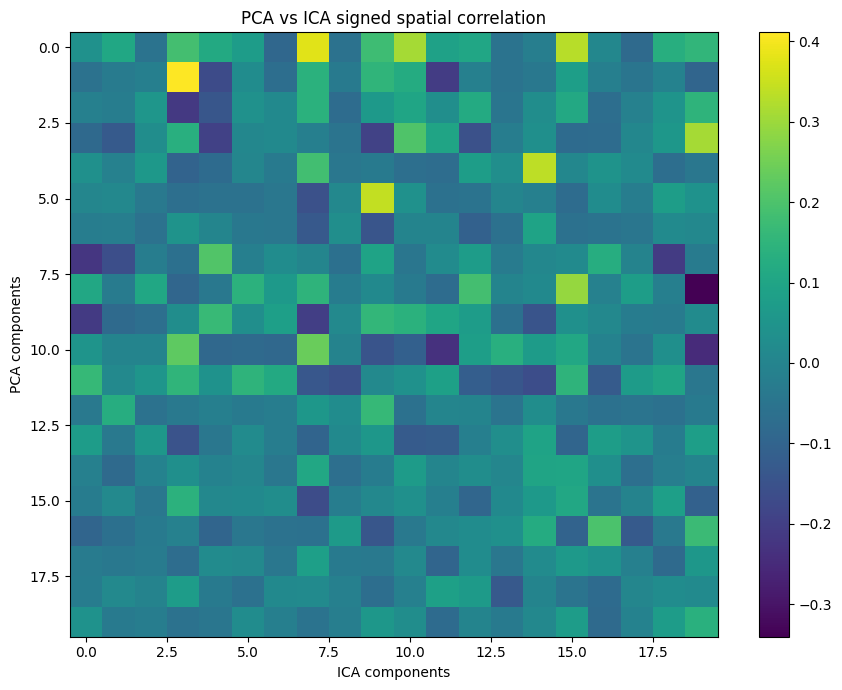

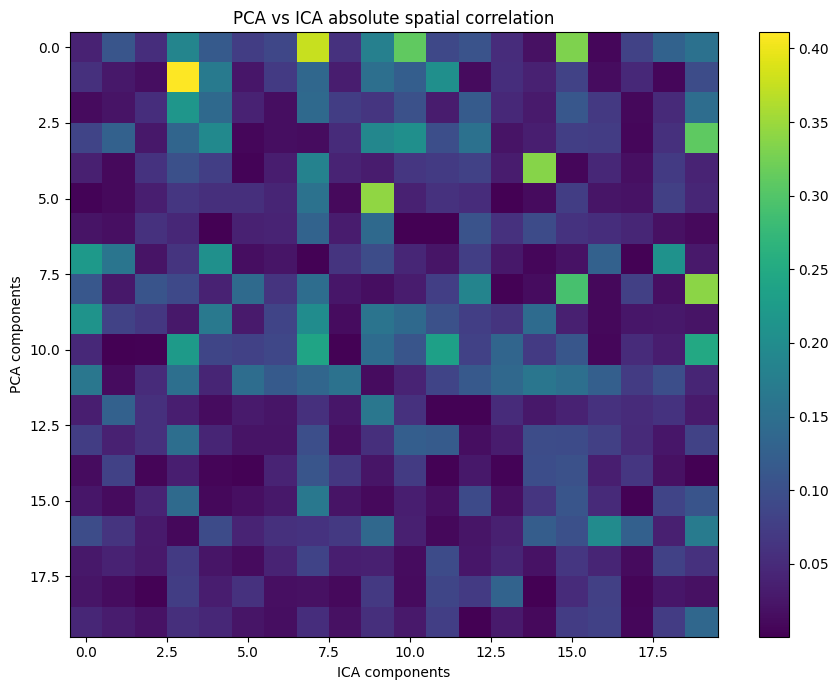

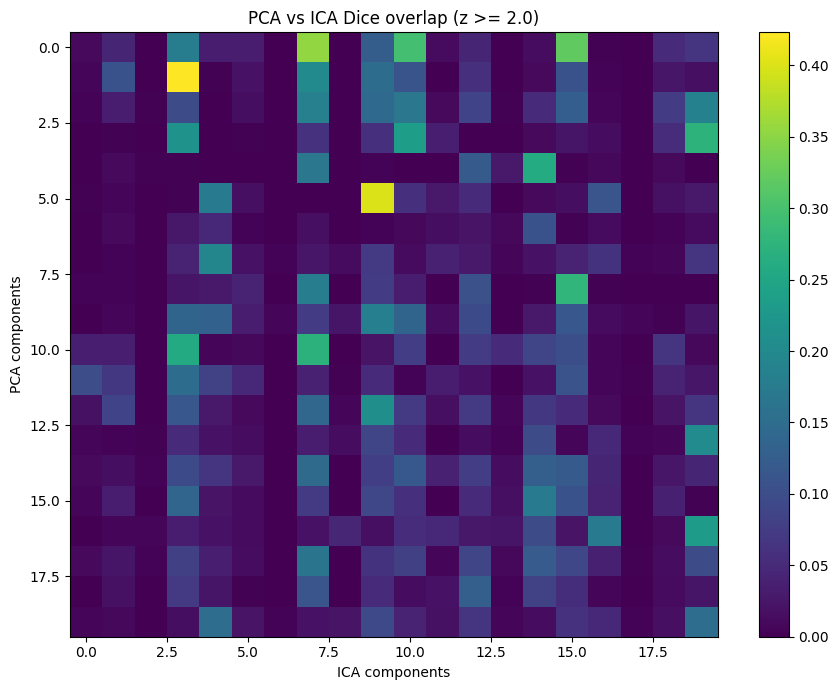

In [9]:

def heatmap(mat: np.ndarray, title: str, xlabel: str, ylabel: str, save_name: Optional[str] = None):
    plt.figure(figsize=(9, 7))
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(OUTDIR / save_name, dpi=200, bbox_inches="tight")
    plt.show()

heatmap(signed_r, "PCA vs ICA signed spatial correlation", "ICA components", "PCA components", "heatmap_signed_corr.png")
heatmap(abs_r, "PCA vs ICA absolute spatial correlation", "ICA components", "PCA components", "heatmap_abs_corr.png")
heatmap(dice_mat, f"PCA vs ICA Dice overlap (z >= {THRESHOLD_Z})", "ICA components", "PCA components", "heatmap_dice.png")


## 5) Greedy and optimal matching


In [10]:

def greedy_match(score_matrix: np.ndarray) -> pd.DataFrame:
    M = score_matrix.copy()
    used_rows = set()
    used_cols = set()
    rows = []

    n_r, n_c = M.shape
    n_pairs = min(n_r, n_c)

    for _ in range(n_pairs):
        best = None
        best_score = -np.inf
        for i in range(n_r):
            if i in used_rows:
                continue
            for j in range(n_c):
                if j in used_cols:
                    continue
                s = M[i, j]
                if s > best_score:
                    best_score = s
                    best = (i, j)
        if best is None:
            break
        i, j = best
        used_rows.add(i)
        used_cols.add(j)
        rows.append({"pca_index": i + 1, "ica_index": j + 1, "score": float(best_score)})

    return pd.DataFrame(rows)

def optimal_match(score_matrix: np.ndarray) -> pd.DataFrame:
    cost = -score_matrix
    r_idx, c_idx = linear_sum_assignment(cost)
    out = pd.DataFrame({
        "pca_index": r_idx + 1,
        "ica_index": c_idx + 1,
        "score": score_matrix[r_idx, c_idx],
    }).sort_values("pca_index").reset_index(drop=True)
    return out

greedy_abs = greedy_match(abs_r)
greedy_dice = greedy_match(dice_mat)
opt_abs = optimal_match(abs_r)
opt_dice = optimal_match(dice_mat)

greedy_abs.to_csv(OUTDIR / "greedy_match_abs_corr.csv", index=False)
greedy_dice.to_csv(OUTDIR / "greedy_match_dice.csv", index=False)
opt_abs.to_csv(OUTDIR / "optimal_match_abs_corr.csv", index=False)
opt_dice.to_csv(OUTDIR / "optimal_match_dice.csv", index=False)

display(greedy_abs.head(10))
display(opt_abs.head(10))


,pca_index,ica_index,score
0,2,4,0.410960
1,1,8,0.376450
2,6,10,0.342757
3,9,20,0.340227
4,5,15,0.336843
5,11,12,0.233876
6,8,1,0.222084
7,4,11,0.205523
8,17,17,0.198758
9,10,5,0.167228


,pca_index,ica_index,score
0,1,8,0.376450
1,2,4,0.410960
2,3,5,0.140475
3,4,20,0.309092
4,5,15,0.336843
5,6,10,0.342757
6,7,3,0.058434
7,8,19,0.209667
8,9,16,0.291118
9,10,1,0.212131


## 6) Add top-component information to the matches


In [11]:

def build_rank_map(df: pd.DataFrame) -> Dict[str, int]:
    return {c: i + 1 for i, c in enumerate(df["component"].tolist())}

pca_rank_map = build_rank_map(pca_importance)
ica_rank_map = build_rank_map(ica_importance)

pca_auc_map = dict(zip(pca_single_auc["component"], pca_single_auc["loocv_auc"]))
ica_auc_map = dict(zip(ica_single_auc["component"], ica_single_auc["loocv_auc"]))

def decorate_match_table(match_df: pd.DataFrame, score_name: str) -> pd.DataFrame:
    out = match_df.copy()
    out["PCA_component"] = out["pca_index"].map(lambda i: f"PC{i:02d}")
    out["ICA_component"] = out["ica_index"].map(lambda i: f"IC{i:02d}")
    out["PCA_rank_by_importance"] = out["PCA_component"].map(pca_rank_map)
    out["ICA_rank_by_importance"] = out["ICA_component"].map(ica_rank_map)
    out["PCA_single_component_auc"] = out["PCA_component"].map(pca_auc_map)
    out["ICA_single_component_auc"] = out["ICA_component"].map(ica_auc_map)
    out = out.rename(columns={"score": score_name})
    return out

match_abs_interp = decorate_match_table(opt_abs, "abs_spatial_corr")
match_dice_interp = decorate_match_table(opt_dice, "dice_overlap")

match_abs_interp.to_csv(OUTDIR / "matched_components_by_abs_corr_interpretable.csv", index=False)
match_dice_interp.to_csv(OUTDIR / "matched_components_by_dice_interpretable.csv", index=False)

display(match_abs_interp.head(15))
display(match_dice_interp.head(15))


,pca_index,ica_index,abs_spatial_corr,PCA_component,ICA_component,PCA_rank_by_importance,ICA_rank_by_importance,PCA_single_component_auc,ICA_single_component_auc
0,1,8,0.376450,PC01,IC08,15,8,0.296970,0.684848
1,2,4,0.410960,PC02,IC04,18,14,0.460606,0.387879
2,3,5,0.140475,PC03,IC05,17,11,0.266667,0.557576
3,4,20,0.309092,PC04,IC20,20,3,0.387879,0.751515
4,5,15,0.336843,PC05,IC15,9,5,0.600000,0.515152
5,6,10,0.342757,PC06,IC10,4,9,0.533333,0.539394
6,7,3,0.058434,PC07,IC03,6,20,0.709091,0.212121
7,8,19,0.209667,PC08,IC19,7,1,0.503030,0.666667
8,9,16,0.291118,PC09,IC16,2,17,0.672727,0.533333
9,10,1,0.212131,PC10,IC01,3,4,0.696970,0.587879


,pca_index,ica_index,dice_overlap,PCA_component,ICA_component,PCA_rank_by_importance,ICA_rank_by_importance,PCA_single_component_auc,ICA_single_component_auc
0,1,11,0.296511,PC01,IC11,15,12,0.296970,0.503030
1,2,4,0.423124,PC02,IC04,18,14,0.460606,0.387879
2,3,19,0.073098,PC03,IC19,17,1,0.266667,0.666667
3,4,20,0.273982,PC04,IC20,20,3,0.387879,0.751515
4,5,15,0.259518,PC05,IC15,9,5,0.600000,0.515152
5,6,10,0.400476,PC06,IC10,4,9,0.533333,0.539394
6,7,7,0.000029,PC07,IC07,6,10,0.709091,0.309091
7,8,5,0.194730,PC08,IC05,7,11,0.503030,0.557576
8,9,16,0.278736,PC09,IC16,2,17,0.672727,0.533333
9,10,6,0.031735,PC10,IC06,3,6,0.696970,0.393939


## 7) Focus on the top components only

This is often the cleanest table for a paper or slides.


In [12]:

top_pca = set(pca_importance["component"].head(10))
top_ica = set(ica_importance["component"].head(10))

top_match_abs = match_abs_interp[
    match_abs_interp["PCA_component"].isin(top_pca) |
    match_abs_interp["ICA_component"].isin(top_ica)
].copy()

top_match_abs = top_match_abs.sort_values(
    ["PCA_rank_by_importance", "ICA_rank_by_importance"],
    na_position="last"
).reset_index(drop=True)

top_match_abs.to_csv(OUTDIR / "top_component_matches_abs_corr.csv", index=False)
display(top_match_abs)


,pca_index,ica_index,abs_spatial_corr,PCA_component,ICA_component,PCA_rank_by_importance,ICA_rank_by_importance,PCA_single_component_auc,ICA_single_component_auc
0,11,12,0.233876,PC11,IC12,1,7,0.727273,0.727273
1,9,16,0.291118,PC09,IC16,2,17,0.672727,0.533333
2,10,1,0.212131,PC10,IC01,3,4,0.696970,0.587879
3,6,10,0.342757,PC06,IC10,4,9,0.533333,0.539394
4,12,9,0.155673,PC12,IC09,5,15,0.527273,0.333333
5,7,3,0.058434,PC07,IC03,6,20,0.709091,0.212121
6,8,19,0.209667,PC08,IC19,7,1,0.503030,0.666667
7,17,17,0.198758,PC17,IC17,8,19,0.521212,0.387879
8,5,15,0.336843,PC05,IC15,9,5,0.600000,0.515152
9,15,18,0.065418,PC15,IC18,10,2,0.551515,0.339394


## 8) Interpretation helper table

This table is meant for writing results text.


In [13]:

def interpretation_table() -> pd.DataFrame:
    rows = []
    for _, row in top_match_abs.iterrows():
        p_auc = row["PCA_single_component_auc"]
        i_auc = row["ICA_single_component_auc"]
        spatial = row["abs_spatial_corr"]

        if spatial >= 0.50 and p_auc >= 0.60 and i_auc >= 0.60:
            note = "Strong spatial match and both are predictive."
        elif spatial >= 0.50 and (p_auc >= 0.60) != (i_auc >= 0.60):
            note = "Spatially similar, but predictive strength differs."
        elif spatial < 0.30 and p_auc >= 0.60 and i_auc >= 0.60:
            note = "Both predictive but likely capturing different structures."
        elif p_auc >= 0.60 and i_auc < 0.60:
            note = "More informative in PCA representation."
        elif i_auc >= 0.60 and p_auc < 0.60:
            note = "More informative in ICA representation."
        else:
            note = "Weak or mixed evidence."
        rows.append({
            **row.to_dict(),
            "interpretation_note": note
        })
    return pd.DataFrame(rows)

interp_df = interpretation_table()
interp_df.to_csv(OUTDIR / "top_component_interpretation_table.csv", index=False)
display(interp_df)


,pca_index,ica_index,abs_spatial_corr,PCA_component,ICA_component,PCA_rank_by_importance,ICA_rank_by_importance,PCA_single_component_auc,ICA_single_component_auc,interpretation_note
0,11,12,0.233876,PC11,IC12,1,7,0.727273,0.727273,Both predictive but likely capturing different...
1,9,16,0.291118,PC09,IC16,2,17,0.672727,0.533333,More informative in PCA representation.
2,10,1,0.212131,PC10,IC01,3,4,0.696970,0.587879,More informative in PCA representation.
3,6,10,0.342757,PC06,IC10,4,9,0.533333,0.539394,Weak or mixed evidence.
4,12,9,0.155673,PC12,IC09,5,15,0.527273,0.333333,Weak or mixed evidence.
5,7,3,0.058434,PC07,IC03,6,20,0.709091,0.212121,More informative in PCA representation.
6,8,19,0.209667,PC08,IC19,7,1,0.503030,0.666667,More informative in ICA representation.
7,17,17,0.198758,PC17,IC17,8,19,0.521212,0.387879,Weak or mixed evidence.
8,5,15,0.336843,PC05,IC15,9,5,0.600000,0.515152,More informative in PCA representation.
9,15,18,0.065418,PC15,IC18,10,2,0.551515,0.339394,Weak or mixed evidence.


## 9) Optional next extension

A very strong next analysis is to compare **subject-level scores** for matched components.

That requires either:

- per-subject PCA/ICA component scores, or
- per-subject summary features that can be aligned by component

If you want, I can turn that into a third notebook that:
- loads per-subject timecourse files
- derives matched PCA vs ICA subject summaries
- compares whether each matched pair varies similarly across people
- builds figure-ready summary plots
